<a href="https://colab.research.google.com/github/Kshashi22/TATA_Online_Retail/blob/main/TATA_Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# **Load Dataset**

In [4]:
file_path = "Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully
Rows: 541909
Columns: 8


# **Basic Inspection**

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [9]:
df.shape

(541909, 8)

In [10]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


# **Dataset Statistics**

In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [12]:
df.describe(include="object")

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


# **Missing Value Analysis**

In [13]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": df.isnull().sum() / len(df) * 100
})

missing.sort_values(
    "Missing %",
    ascending=False
)



,Missing Values,Missing %
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


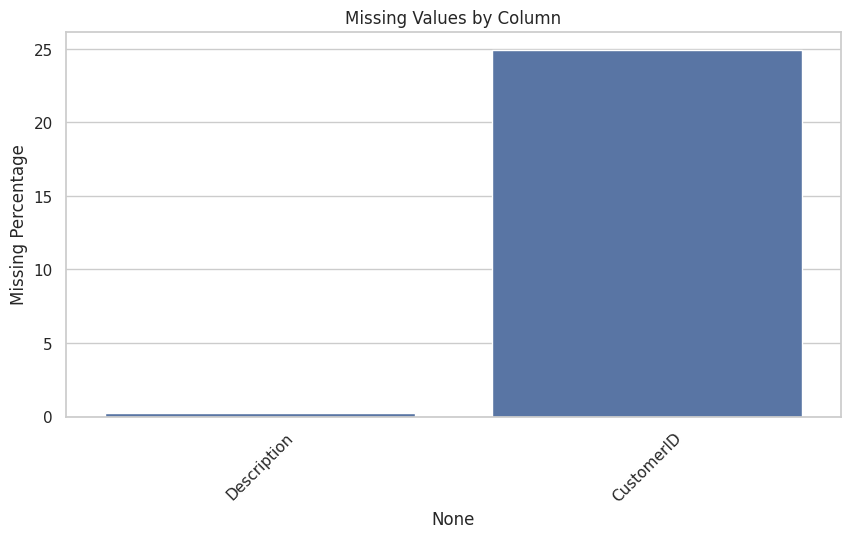

In [14]:
missing_plot = missing[
    missing["Missing Values"] > 0
]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_plot.index,
    y=missing_plot["Missing %"]
)

plt.title("Missing Values by Column")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=45)

plt.show()

# **Duplicate Analysis**

In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [16]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (536641, 8)


# **Data Cleaning**

In [17]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [18]:
print(
    "Negative quantity records:",
    (df["Quantity"] < 0).sum()
)

Negative quantity records: 10587


In [19]:
print(
    "Non-positive prices:",
    (df["UnitPrice"] <= 0).sum()
)

Non-positive prices: 2512


# **Identify Cancelled Orders**

In [20]:
df["IsCancelled"] = (
    df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

df["IsCancelled"].value_counts()

,count
IsCancelled,
False,527390
True,9251


In [21]:
cancellation_rate = (
    df["IsCancelled"].mean() * 100
)

print(
    f"Cancellation Rate: {cancellation_rate:.2f}%"
)

Cancellation Rate: 1.72%


# **Create Revenue Column**

In [22]:
df["Revenue"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

In [23]:
sales_df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (~df["IsCancelled"])
].copy()

print("Valid sales records:", len(sales_df))

Valid sales records: 524878


# **Create Date Features**

In [24]:
sales_df["Year"] = (
    sales_df["InvoiceDate"].dt.year
)

sales_df["Month"] = (
    sales_df["InvoiceDate"].dt.month
)

sales_df["Month Name"] = (
    sales_df["InvoiceDate"].dt.month_name()
)

sales_df["Quarter"] = (
    sales_df["InvoiceDate"].dt.quarter
)

sales_df["Day"] = (
    sales_df["InvoiceDate"].dt.day
)

sales_df["Day Name"] = (
    sales_df["InvoiceDate"].dt.day_name()
)

sales_df["Hour"] = (
    sales_df["InvoiceDate"].dt.hour
)

# **Main Business KPIs**

In [25]:
total_revenue = sales_df["Revenue"].sum()

total_orders = sales_df["InvoiceNo"].nunique()

total_customers = sales_df["CustomerID"].nunique()

total_products = sales_df["StockCode"].nunique()

total_units = sales_df["Quantity"].sum()

average_order_value = (
    total_revenue / total_orders
)

average_units_per_order = (
    total_units / total_orders
)

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")
print(f"Average Units per Order: {average_units_per_order:.2f}")

Total Revenue: £10,642,110.80
Total Orders: 19,960
Total Customers: 4,338
Total Products: 3,922
Total Units Sold: 5,572,420
Average Order Value: £533.17
Average Units per Order: 279.18


# **Revenue Trend by Year**

In [26]:
yearly_sales = sales_df.groupby(
    "Year"
).agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Customers=("CustomerID", "nunique"),
    Units=("Quantity", "sum")
).reset_index()

yearly_sales

,Year,Revenue,Orders,Customers,Units
0,2010,821452.730,1559,885,358019
1,2011,9820658.074,18401,4219,5214401


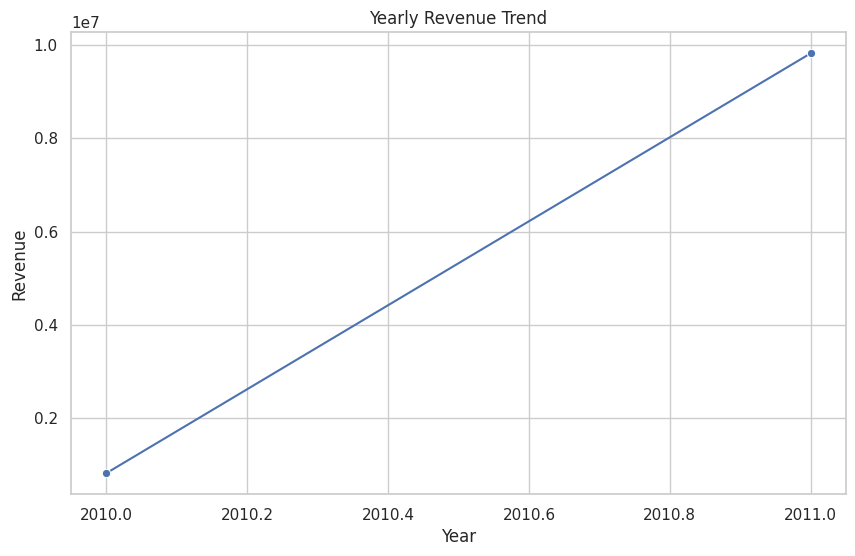

In [27]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly_sales,
    x="Year",
    y="Revenue",
    marker="o"
)

plt.title("Yearly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

# **Year-over-Year Growth**

In [28]:
yearly_sales["Revenue Growth %"] = (
    yearly_sales["Revenue"]
    .pct_change() * 100
)

yearly_sales

,Year,Revenue,Orders,Customers,Units,Revenue Growth %
0,2010,821452.730,1559,885,358019,NaN
1,2011,9820658.074,18401,4219,5214401,1095.523213


# **Monthly Revenue Trend**

In [29]:
monthly_sales = sales_df.groupby(
    sales_df["InvoiceDate"].dt.to_period("M")
).agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Customers=("CustomerID", "nunique")
).reset_index()

monthly_sales["Month"] = (
    monthly_sales["InvoiceDate"]
    .astype(str)
)

monthly_sales

,InvoiceDate,Revenue,Orders,Customers,Month
0,2010-12,821452.730,1559,885,2010-12
1,2011-01,689811.610,1086,741,2011-01
2,2011-02,522545.560,1100,758,2011-02
3,2011-03,716215.260,1454,974,2011-03
4,2011-04,536968.491,1246,856,2011-04
5,2011-05,769296.610,1681,1056,2011-05
6,2011-06,760547.010,1533,991,2011-06
7,2011-07,718076.121,1475,949,2011-07
8,2011-08,757841.380,1361,935,2011-08
9,2011-09,1056435.192,1837,1266,2011-09


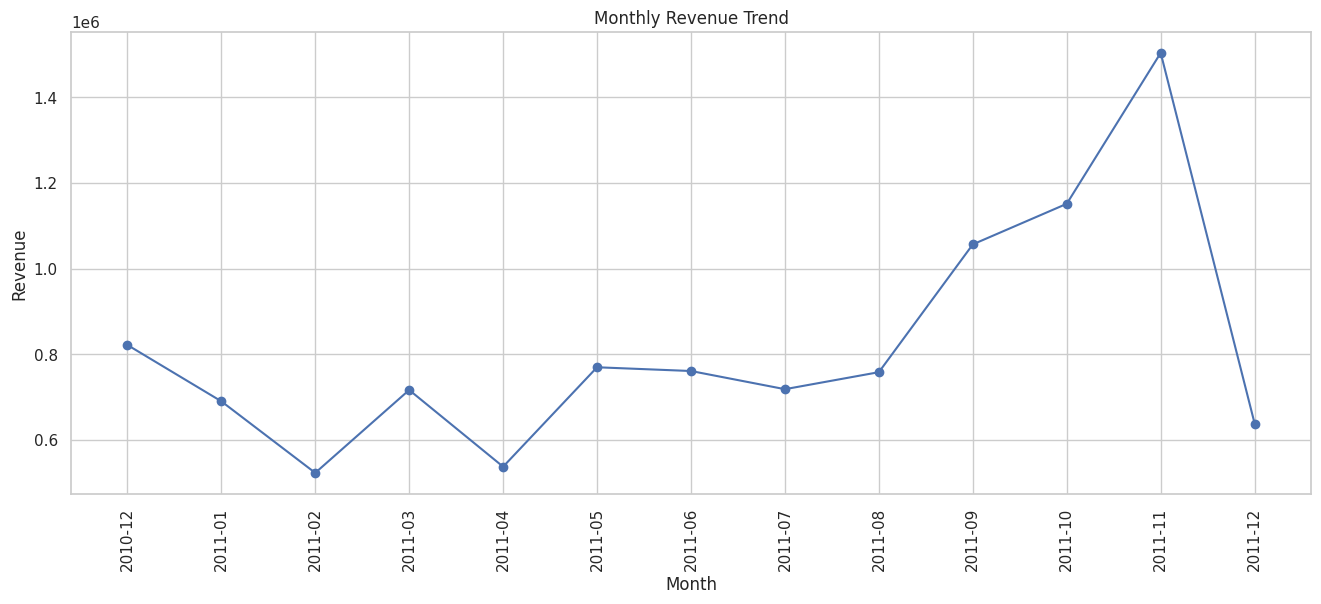

In [30]:
plt.figure(figsize=(16, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

# **Monthly Orders**

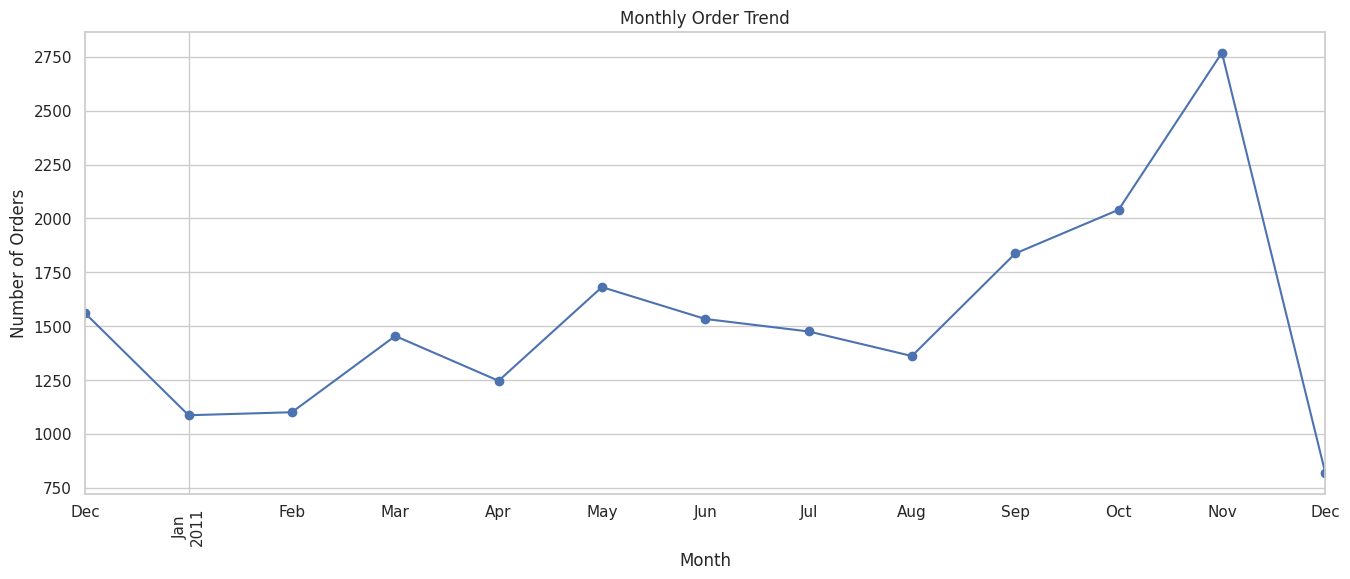

In [31]:
monthly_orders = sales_df.groupby(
    sales_df["InvoiceDate"].dt.to_period("M")
)["InvoiceNo"].nunique()

plt.figure(figsize=(16, 6))

monthly_orders.plot(
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=90)

plt.show()

# **Quarterly Analysis**

In [32]:
quarterly = sales_df.groupby(
    ["Year", "Quarter"]
).agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Customers=("CustomerID", "nunique")
).reset_index()

quarterly

,Year,Quarter,Revenue,Orders,Customers
0,2010,4,821452.730,1559,885
1,2011,1,1928572.430,3640,1776
2,2011,2,2066812.111,4460,1991
3,2011,3,2532352.693,4673,2161
4,2011,4,3292920.840,5628,2560


# **Country Analysis**

In [33]:
country = sales_df.groupby(
    "Country"
).agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Customers=("CustomerID", "nunique"),
    Units=("Quantity", "sum")
).reset_index()

country.sort_values(
    "Revenue",
    ascending=False
).head(20)

,Country,Revenue,Orders,Customers,Units
36,United Kingdom,9001744.094,18019,3920,4646906
24,Netherlands,285446.340,94,9,200361
10,EIRE,283140.520,288,3,147007
14,Germany,228678.400,457,94,119154
13,France,209625.370,392,87,112060
0,Australia,138453.810,57,9,83891
31,Spain,61558.560,90,30,27933
33,Switzerland,57067.600,54,21,30617
3,Belgium,41196.340,98,25,23237
32,Sweden,38367.830,36,8,36078


# **Top 10 Countries by Revenue**

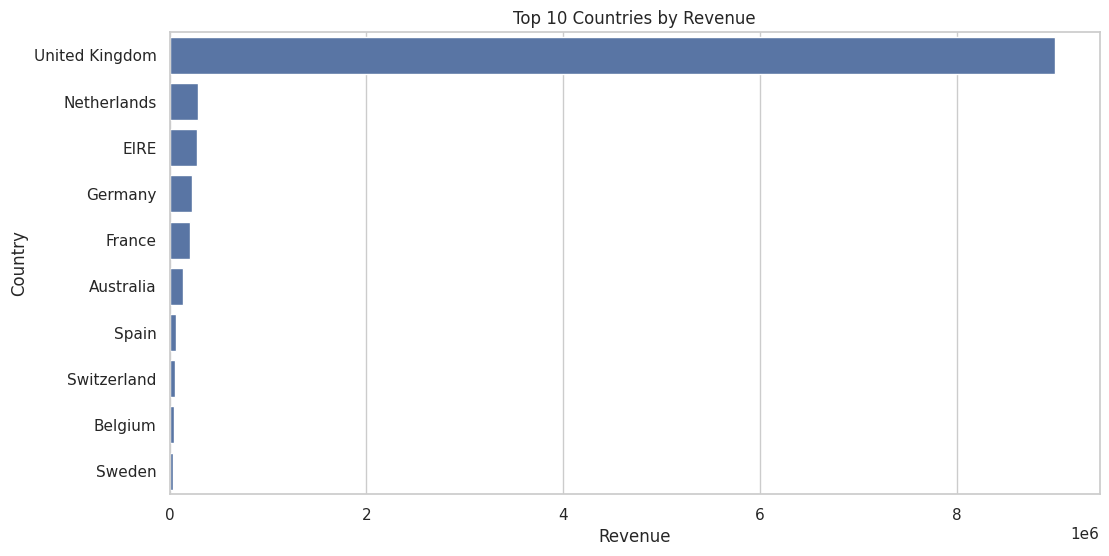

In [34]:
top_countries = country.sort_values(
    "Revenue",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_countries,
    x="Revenue",
    y="Country"
)

plt.title("Top 10 Countries by Revenue")

plt.show()

# **Revenue by Country**

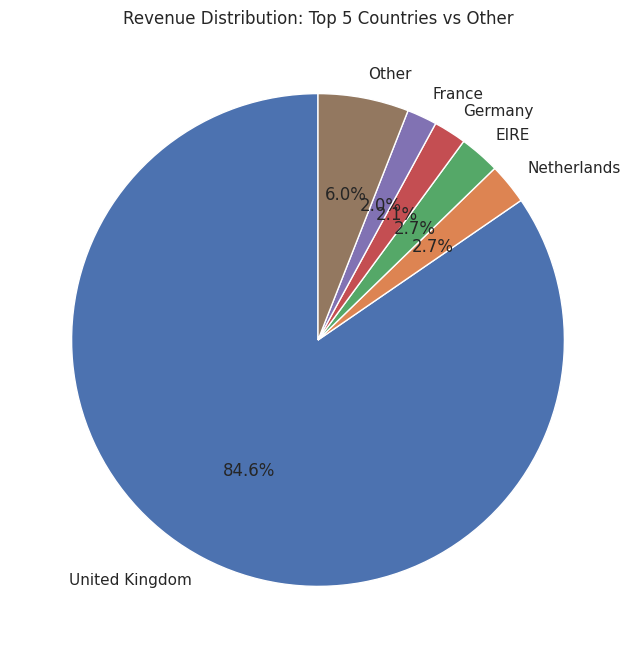

In [35]:
country_sales = (
    country
    .sort_values("Revenue", ascending=False)
)

top5 = country_sales.head(5).copy()

other_revenue = (
    country_sales.iloc[5:]["Revenue"].sum()
)

pie_data = pd.concat([
    top5[["Country", "Revenue"]],
    pd.DataFrame({
        "Country": ["Other"],
        "Revenue": [other_revenue]
    })
])

plt.figure(figsize=(8, 8))

plt.pie(
    pie_data["Revenue"],
    labels=pie_data["Country"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Distribution: Top 5 Countries vs Other")

plt.show()

# **UK vs International Revenue**

In [36]:
sales_df["Market"] = np.where(
    sales_df["Country"] == "United Kingdom",
    "United Kingdom",
    "International"
)

market = sales_df.groupby(
    "Market"
)["Revenue"].sum()

market

,Revenue
Market,
International,1640366.710
United Kingdom,9001744.094


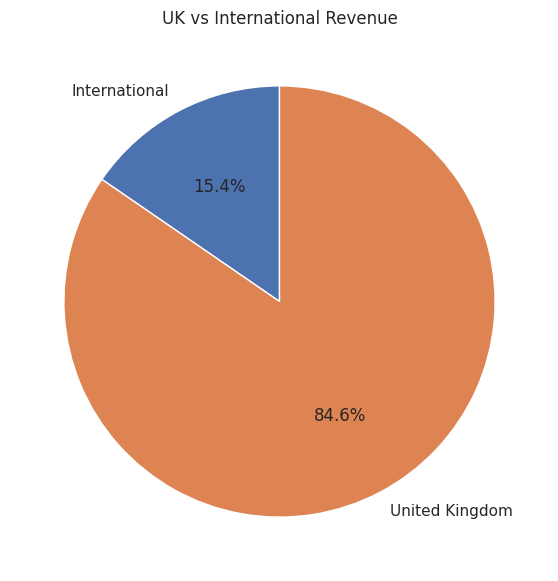

In [37]:
plt.figure(figsize=(7, 7))

plt.pie(
    market,
    labels=market.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("UK vs International Revenue")

plt.show()

# **Product Analysis**

In [38]:
product = sales_df.groupby(
    ["StockCode", "Description"]
).agg(
    Revenue=("Revenue", "sum"),
    Units=("Quantity", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Average_Price=("UnitPrice", "mean")
).reset_index()

In [39]:
product.sort_values(
    "Revenue",
    ascending=False
).head(20)

,StockCode,Description,Revenue,Units,Orders,Average_Price
4150,DOT,DOTCOM POSTAGE,206248.77,706,706,292.137068
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988,13.983936
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189,3.116159
2669,47566,PARTY BUNTING,99445.23,18283,1685,5.797928
3761,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089,2.486197
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,1.468480
4153,POST,POSTAGE,78101.88,3150,1126,31.076581
4151,M,Manual,77750.27,6984,289,234.489652
1951,23084,RABBIT NIGHT LIGHT,66870.03,30739,994,2.386401


# **Top 10 Products by Revenue**

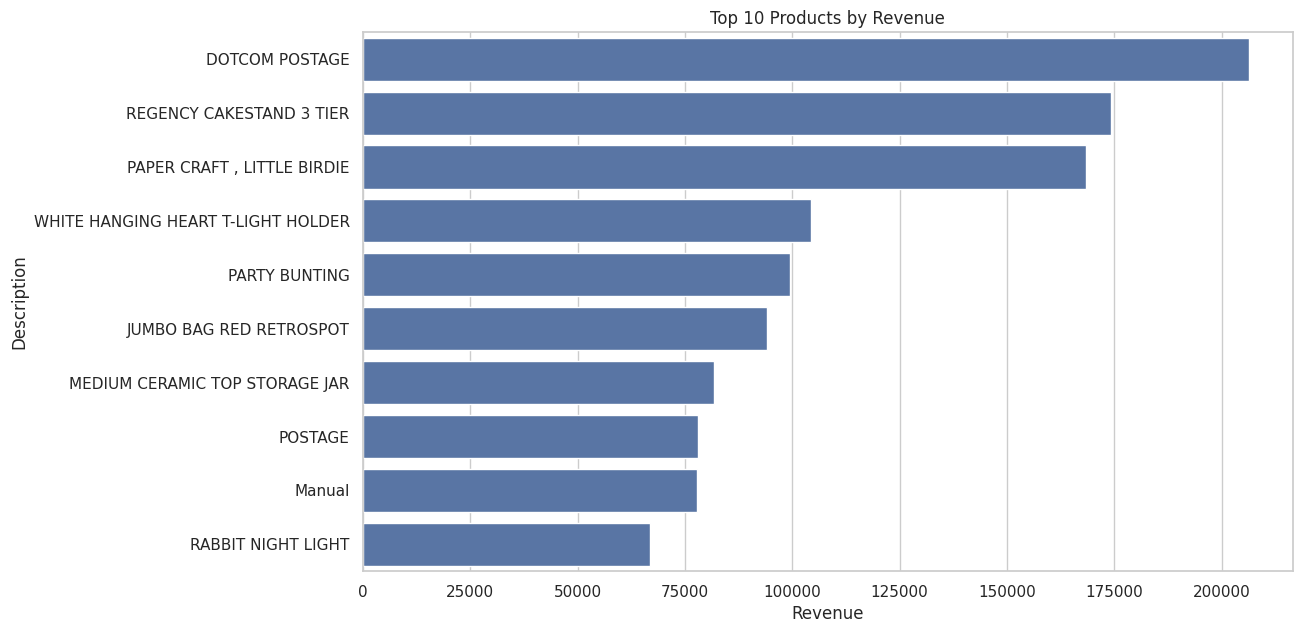

In [40]:
top_products = product.sort_values(
    "Revenue",
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products,
    x="Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")

plt.show()

# **Top Products by Quantity**

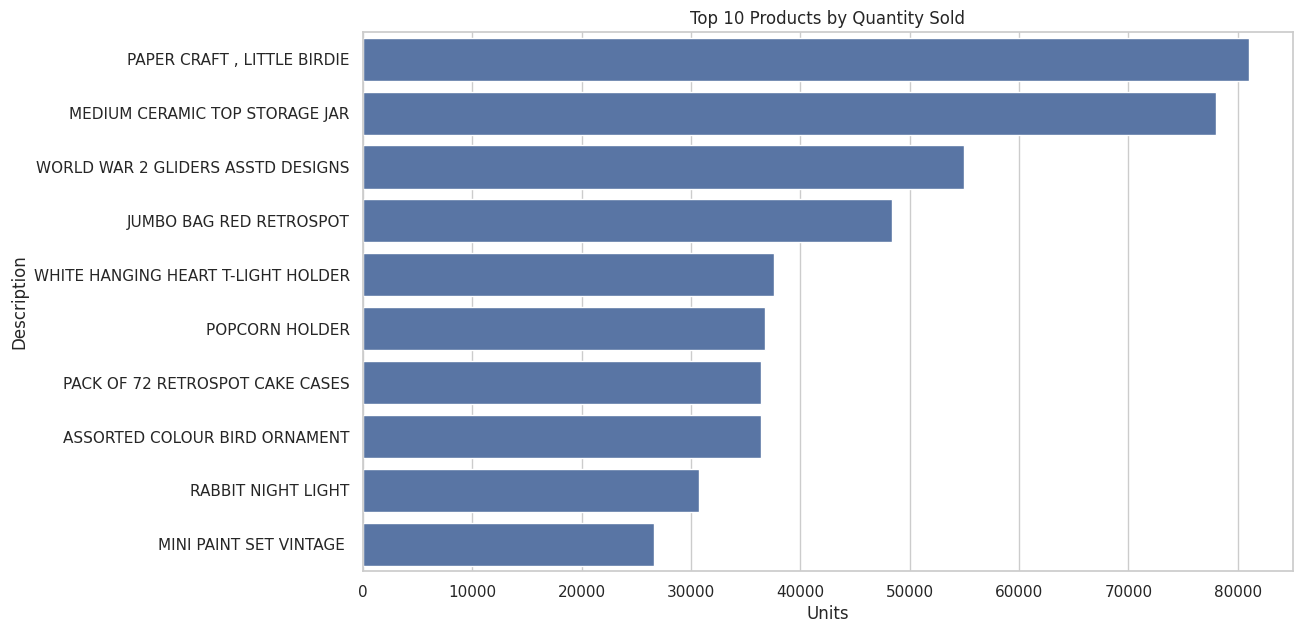

In [41]:
top_quantity = product.sort_values(
    "Units",
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_quantity,
    x="Units",
    y="Description"
)

plt.title("Top 10 Products by Quantity Sold")

plt.show()


# **Average Product Price**

In [42]:
print(
    f"Average Unit Price: £{sales_df['UnitPrice'].mean():.2f}"
)

print(
    f"Median Unit Price: £{sales_df['UnitPrice'].median():.2f}"
)

Average Unit Price: £3.92
Median Unit Price: £2.08


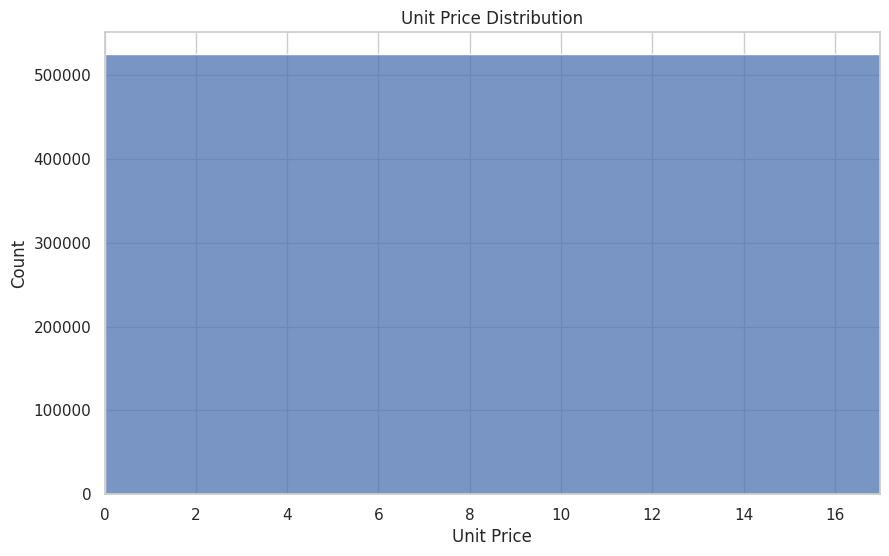

In [43]:
plt.figure(figsize=(10, 6))

sns.histplot(
    sales_df["UnitPrice"],
    bins=50
)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")

plt.xlim(
    0,
    sales_df["UnitPrice"].quantile(0.99)
)

plt.show()

# **Customer Analysis**

In [44]:
customer = sales_df.groupby(
    "CustomerID"
).agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Units=("Quantity", "sum"),
    Average_Order_Value=("Revenue", "mean")
).reset_index()

customer.head()

,CustomerID,Revenue,Orders,Units,Average_Order_Value
0,12346.0,77183.60,1,74215,77183.600000
1,12347.0,4310.00,7,2458,23.681319
2,12348.0,1797.24,4,2341,57.975484
3,12349.0,1757.55,1,631,24.076027
4,12350.0,334.40,1,197,19.670588


# **Top 10 Customers**

In [45]:
top_customers = customer.sort_values(
    "Revenue",
    ascending=False
).head(10)

top_customers

,CustomerID,Revenue,Orders,Units,Average_Order_Value
1689,14646.0,280206.02,73,196915,134.973998
4201,18102.0,259657.30,60,64124,602.453132
3728,17450.0,194390.79,46,69973,578.544018
3008,16446.0,168472.50,2,80997,56157.500000
1879,14911.0,143711.17,201,80240,25.345885
55,12415.0,124914.53,21,77374,174.950322
1333,14156.0,117210.08,55,57768,84.021563
3771,17511.0,91062.38,31,64549,94.561142
2702,16029.0,80850.84,63,40108,335.480664
0,12346.0,77183.60,1,74215,77183.600000


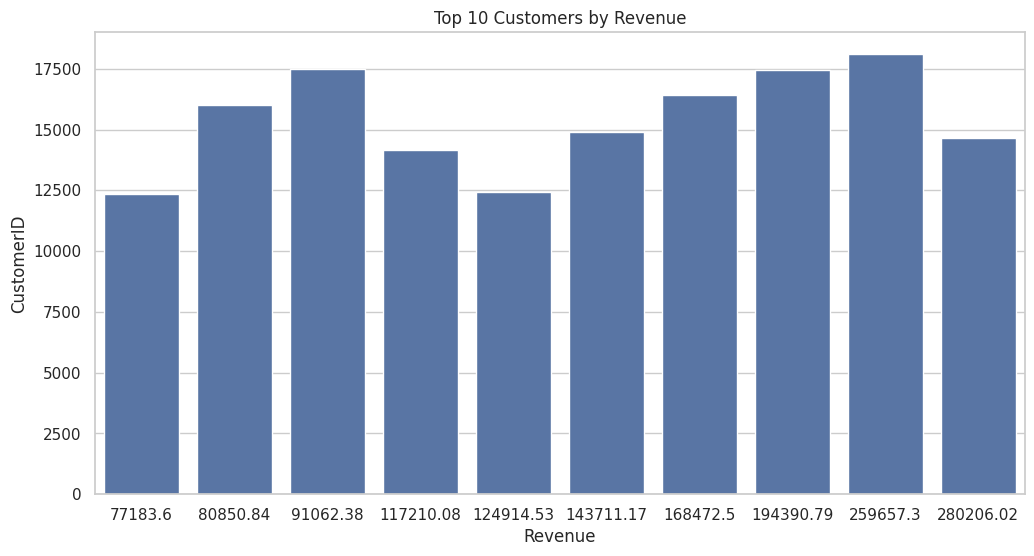

In [47]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_customers,
    x="Revenue",
    y="CustomerID"
)

plt.title("Top 10 Customers by Revenue")

plt.show()

# **Customer Revenue Distribution**

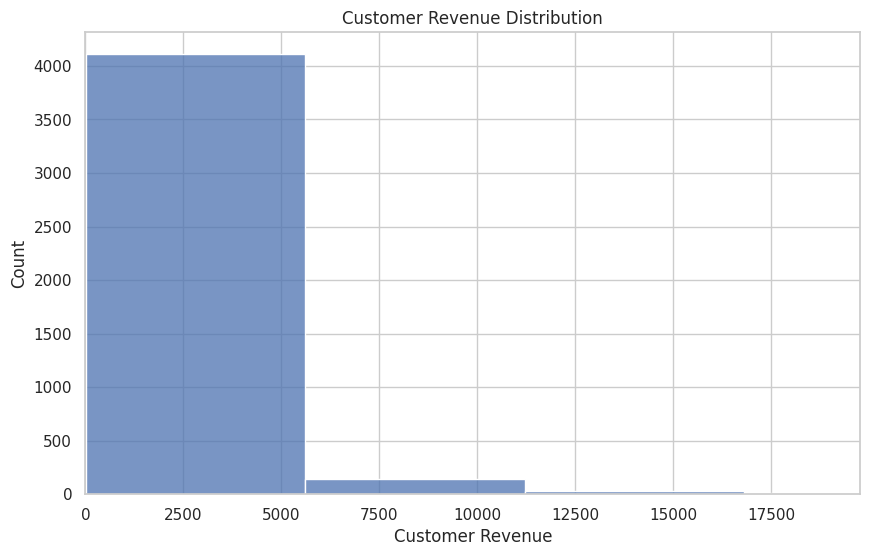

In [48]:
plt.figure(figsize=(10, 6))

sns.histplot(
    customer["Revenue"],
    bins=50
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue")

plt.xlim(
    0,
    customer["Revenue"].quantile(0.99)
)

plt.show()

# **One-Time vs Repeat Customers**

In [49]:
customer["Customer Type"] = np.where(
    customer["Orders"] == 1,
    "One-Time",
    "Repeat"
)

customer_type = customer[
    "Customer Type"
].value_counts()

customer_type

,count
Customer Type,
Repeat,2845
One-Time,1493


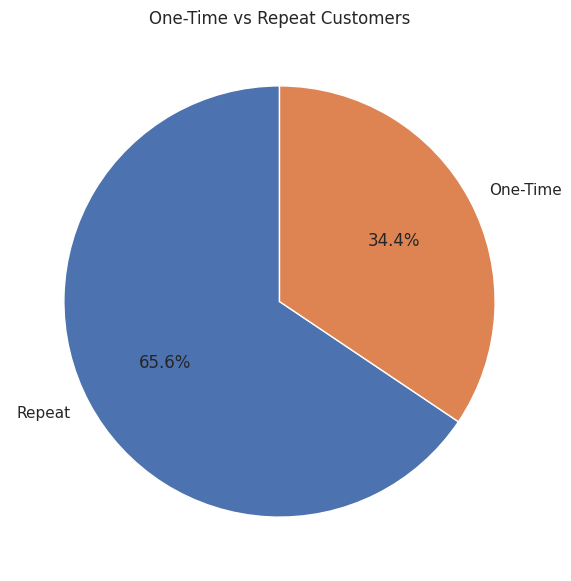

In [50]:
plt.figure(figsize=(7, 7))

plt.pie(
    customer_type,
    labels=customer_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("One-Time vs Repeat Customers")

plt.show()

# **Repeat Customer Rate**

In [51]:
repeat_customers = (
    customer["Orders"] > 1
).sum()

total_customer_count = len(customer)

repeat_rate = (
    repeat_customers /
    total_customer_count * 100
)

print(
    f"Repeat Customer Rate: {repeat_rate:.2f}%"
)

Repeat Customer Rate: 65.58%


# **Order Size Analysis**

In [52]:
order_analysis = sales_df.groupby(
    "InvoiceNo"
).agg(
    Revenue=("Revenue", "sum"),
    Units=("Quantity", "sum"),
    CustomerID=("CustomerID", "first")
).reset_index()

order_analysis.describe()

,Revenue,Units,CustomerID
count,19960.000000,19960.000000,18532.000000
mean,533.171884,279.179359,15266.378211
std,1780.412288,955.011810,1734.116296
min,0.380000,1.000000,12346.000000
25%,151.695000,69.000000,13776.250000
50%,303.300000,150.000000,15178.500000
75%,493.462500,296.000000,16779.000000
max,168469.600000,80995.000000,18287.000000


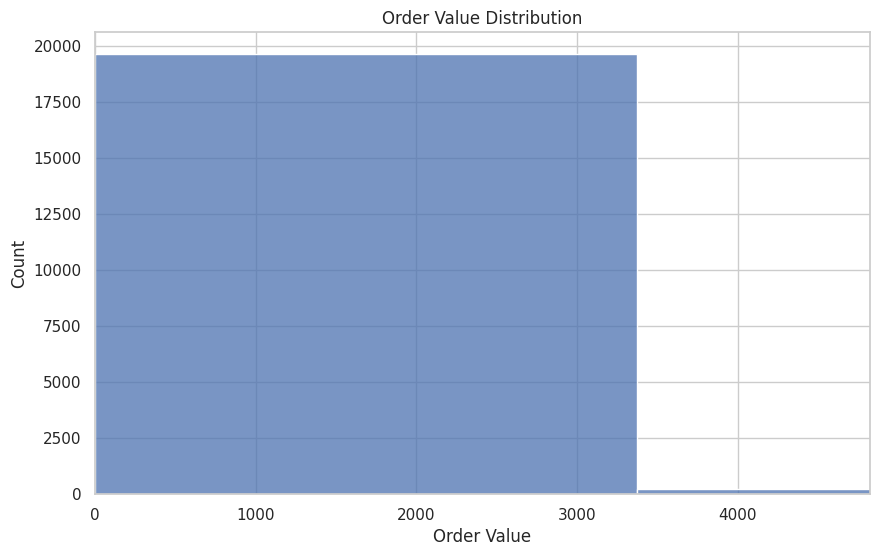

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    order_analysis["Revenue"],
    bins=50
)

plt.title("Order Value Distribution")
plt.xlabel("Order Value")

plt.xlim(
    0,
    order_analysis["Revenue"].quantile(0.99)
)

plt.show()

# **Average Order Value by Country**

In [54]:
country_aov = sales_df.groupby(
    "Country"
).agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique")
).reset_index()

country_aov["AOV"] = (
    country_aov["Revenue"] /
    country_aov["Orders"]
)

country_aov.sort_values(
    "AOV",
    ascending=False
).head(15)

,Country,Revenue,Orders,AOV
30,Singapore,21279.29,7,3039.898571
24,Netherlands,285446.34,94,3036.663191
0,Australia,138453.81,57,2429.014211
20,Japan,37416.37,19,1969.282632
21,Lebanon,1693.88,1,1693.880000
16,Hong Kong,15483.00,11,1407.545455
4,Brazil,1143.60,1,1143.600000
32,Sweden,38367.83,36,1065.773056
33,Switzerland,57067.60,54,1056.807407
9,Denmark,18955.34,18,1053.074444


# **Day-of-Week Analysis**

In [55]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_analysis = sales_df.groupby(
    "Day Name"
).agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Units=("Quantity", "sum")
).reindex(day_order)

day_analysis

,Revenue,Orders,Units
Day Name,,,
Monday,1775782.071,3126.0,871148.0
Tuesday,2175700.511,3554.0,1113087.0
Wednesday,1847074.380,3690.0,1025093.0
Thursday,2199292.570,4246.0,1207384.0
Friday,1837470.491,3140.0,890199.0
Saturday,NaN,NaN,NaN
Sunday,806790.781,2204.0,465509.0


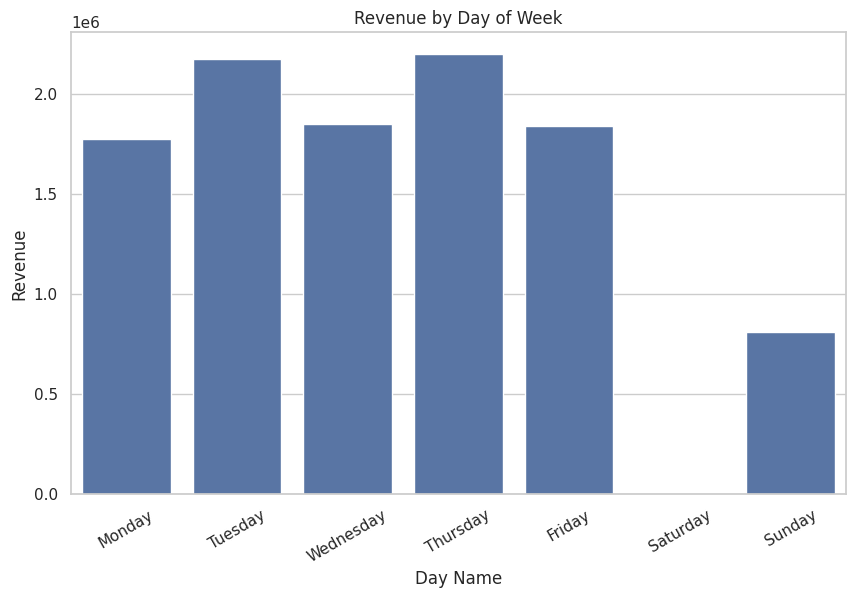

In [56]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=day_analysis.index,
    y=day_analysis["Revenue"]
)

plt.title("Revenue by Day of Week")
plt.xticks(rotation=30)

plt.show()

# **Hourly Sales Analysis**

In [57]:
hourly = sales_df.groupby(
    "Hour"
).agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique")
).reset_index()

hourly

,Hour,Revenue,Orders
0,6,4.250,1
1,7,31059.210,29
2,8,283750.680,566
3,9,990054.991,1484
4,10,1444814.771,2361
5,11,1236573.290,2396
6,12,1439324.660,3220
7,13,1261195.200,2753
8,14,1177907.521,2457
9,15,1350333.310,2336


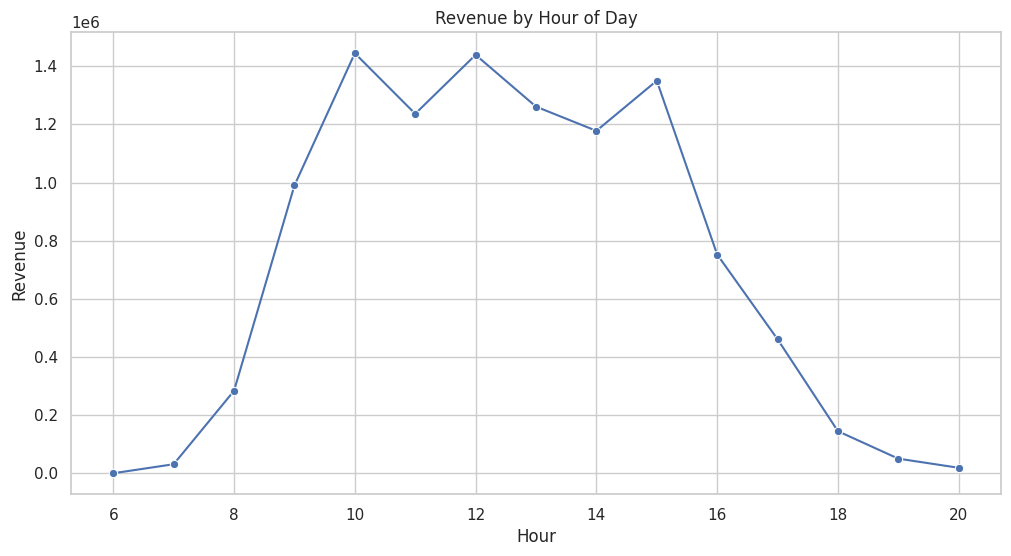

In [58]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly,
    x="Hour",
    y="Revenue",
    marker="o"
)

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.show()

# **Cancellation Analysis**

In [59]:
cancelled = df[
    df["IsCancelled"]
].copy()

cancelled["Cancelled Revenue"] = (
    cancelled["Quantity"].abs() *
    cancelled["UnitPrice"]
)

print(
    "Cancelled records:",
    len(cancelled)
)

print(
    "Cancelled invoices:",
    cancelled["InvoiceNo"].nunique()
)

print(
    "Cancelled quantity:",
    cancelled["Quantity"].abs().sum()
)

Cancelled records: 9251
Cancelled invoices: 3836
Cancelled quantity: 275560


# **Cancellation by Country**

In [60]:
cancel_country = cancelled.groupby(
    "Country"
).agg(
    Cancelled_Quantity=(
        "Quantity",
        lambda x: x.abs().sum()
    ),
    Cancelled_Orders=(
        "InvoiceNo",
        "nunique"
    )
).reset_index()

cancel_country.sort_values(
    "Cancelled_Orders",
    ascending=False
).head(15)

,Country,Cancelled_Quantity,Cancelled_Orders
29,United Kingdom,261044,3372
12,Germany,1815,146
8,EIRE,4786,72
11,France,1623,69
3,Belgium,85,21
27,Switzerland,305,20
16,Italy,113,17
25,Spain,1127,15
22,Portugal,78,13
0,Australia,556,12


# **Cancellation Trend**

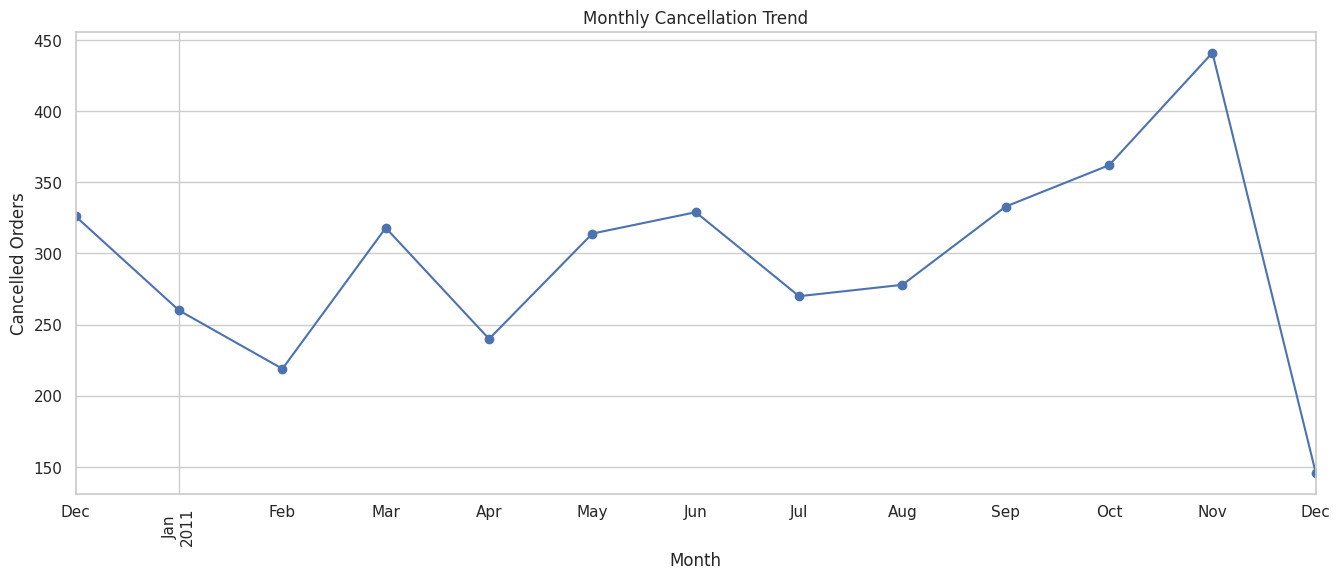

In [61]:
cancelled["Month"] = (
    cancelled["InvoiceDate"]
    .dt.to_period("M")
)

cancellation_monthly = cancelled.groupby(
    "Month"
)["InvoiceNo"].nunique()

plt.figure(figsize=(16, 6))

cancellation_monthly.plot(
    marker="o"
)

plt.title("Monthly Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Cancelled Orders")

plt.xticks(rotation=90)

plt.show()

# **RFM Analysis**

In [62]:
reference_date = (
    sales_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

reference_date

Timestamp('2011-12-10 12:50:00')

In [63]:
rfm = sales_df.groupby(
    "CustomerID"
).agg(
    Recency=(
        "InvoiceDate",
        lambda x: (
            reference_date - x.max()
        ).days
    ),
    Frequency=(
        "InvoiceNo",
        "nunique"
    ),
    Monetary=(
        "Revenue",
        "sum"
    )
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


# **RFM Scores**

In [64]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [65]:
rfm[
    ["R_Score", "F_Score", "M_Score"]
] = rfm[
    ["R_Score", "F_Score", "M_Score"]
].astype(int)

# **RFM Customer Score**

In [66]:
rfm["RFM Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM Score
0,12346.0,326,1,77183.60,1,1,5,115
1,12347.0,2,7,4310.00,5,5,5,555
2,12348.0,75,4,1797.24,2,4,4,244
3,12349.0,19,1,1757.55,4,1,4,414
4,12350.0,310,1,334.40,1,1,2,112


# **Customer Segmentation**

In [67]:
def segment_customer(row):

    if (
        row["R_Score"] >= 4 and
        row["F_Score"] >= 4 and
        row["M_Score"] >= 4
    ):
        return "Champions"

    elif (
        row["R_Score"] >= 4 and
        row["F_Score"] >= 3
    ):
        return "Loyal Customers"

    elif (
        row["R_Score"] >= 4
    ):
        return "Recent Customers"

    elif (
        row["R_Score"] <= 2 and
        row["F_Score"] >= 3
    ):
        return "At Risk"

    elif (
        row["R_Score"] <= 2 and
        row["F_Score"] <= 2
    ):
        return "Lost Customers"

    else:
        return "Potential Loyalists"


rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

# **RFM Segment Distribution**

In [68]:
segment_distribution = (
    rfm["Segment"]
    .value_counts()
)

segment_distribution

,count
Segment,
Lost Customers,1065
Champions,957
Potential Loyalists,858
At Risk,643
Loyal Customers,496
Recent Customers,319


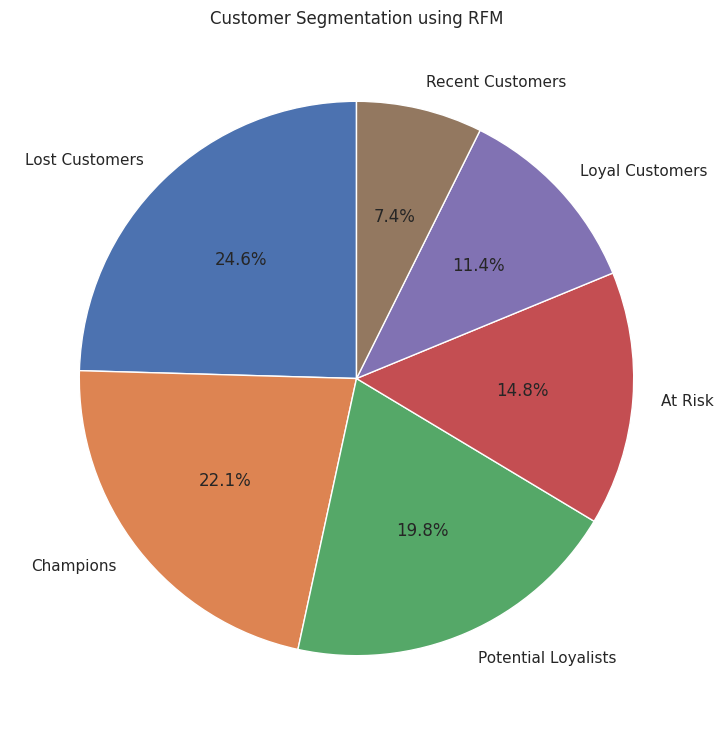

In [69]:
plt.figure(figsize=(9, 9))

plt.pie(
    segment_distribution,
    labels=segment_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Segmentation using RFM")

plt.show()

# **RFM Segment Revenue**

In [70]:
rfm_revenue = rfm.groupby(
    "Segment"
)["Monetary"].sum().sort_values(
    ascending=False
)

rfm_revenue

,Monetary
Segment,
Champions,5791640.740
Potential Loyalists,1099446.880
At Risk,798052.511
Loyal Customers,534526.871
Lost Customers,518322.152
Recent Customers,145219.740


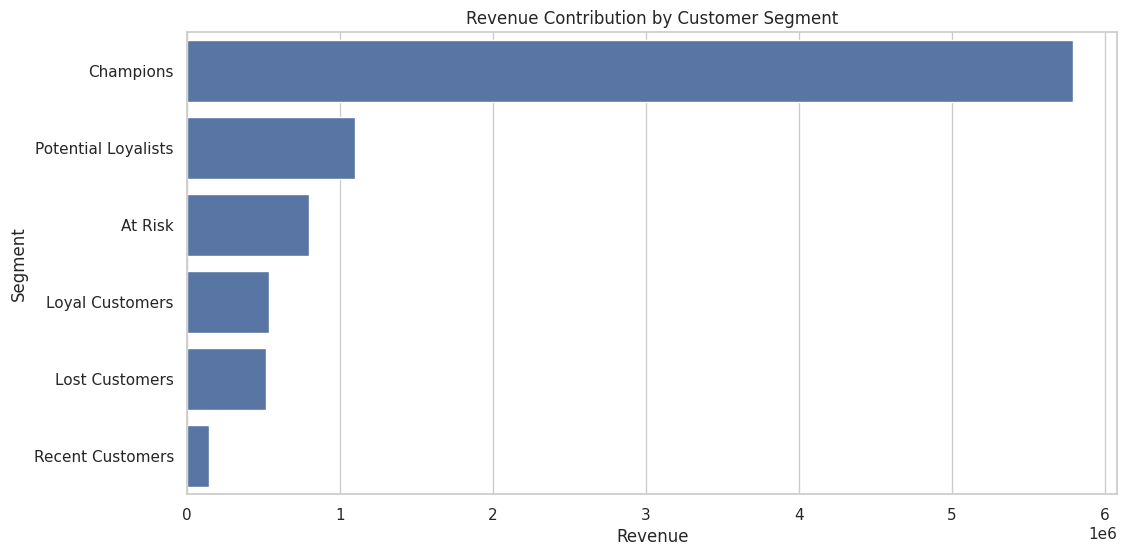

In [71]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=rfm_revenue.values,
    y=rfm_revenue.index
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Revenue")

plt.show()

# **Product Concentration — Pareto Analysis**

In [72]:
product_pareto = product.sort_values(
    "Revenue",
    ascending=False
).copy()

product_pareto["Cumulative Revenue %"] = (
    product_pareto["Revenue"].cumsum() /
    product_pareto["Revenue"].sum() *
    100
)

product_pareto.head(20)

,StockCode,Description,Revenue,Units,Orders,Average_Price,Cumulative Revenue %
4150,DOT,DOTCOM POSTAGE,206248.77,706,706,292.137068,1.938044
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988,13.983936,3.574529
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000,5.157576
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189,3.116159,6.137496
2669,47566,PARTY BUNTING,99445.23,18283,1685,5.797928,7.071946
3761,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089,2.486197,7.956732
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,1.468480,8.724445
4153,POST,POSTAGE,78101.88,3150,1126,31.076581,9.458340
4151,M,Manual,77750.27,6984,289,234.489652,10.188930
1951,23084,RABBIT NIGHT LIGHT,66870.03,30739,994,2.386401,10.817283


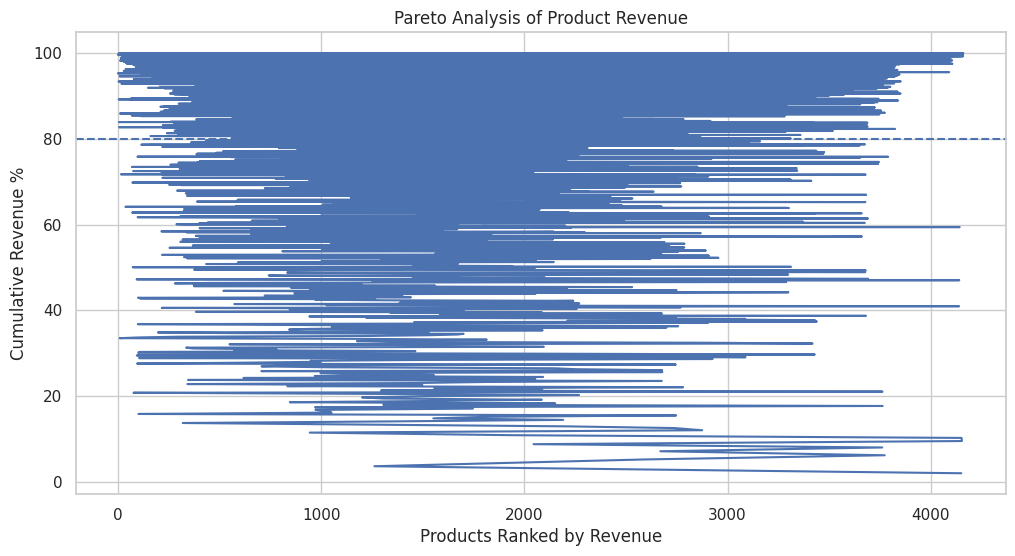

In [73]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    product_pareto.index,
    product_pareto["Cumulative Revenue %"]
)

ax1.axhline(
    80,
    linestyle="--"
)

ax1.set_ylabel("Cumulative Revenue %")
ax1.set_xlabel("Products Ranked by Revenue")

plt.title("Pareto Analysis of Product Revenue")

plt.show()

# **Customer Concentration — Pareto Analysis**

In [74]:
customer_pareto = customer.sort_values(
    "Revenue",
    ascending=False
).copy()

customer_pareto["Cumulative Revenue %"] = (
    customer_pareto["Revenue"].cumsum() /
    customer_pareto["Revenue"].sum() *
    100
)

customer_pareto.head(20)

,CustomerID,Revenue,Orders,Units,Average_Order_Value,Customer Type,Cumulative Revenue %
1689,14646.0,280206.02,73,196915,134.973998,Repeat,3.152914
4201,18102.0,259657.30,60,64124,602.453132,Repeat,6.074610
3728,17450.0,194390.79,46,69973,578.544018,Repeat,8.261920
3008,16446.0,168472.50,2,80997,56157.500000,Repeat,10.157594
1879,14911.0,143711.17,201,80240,25.345885,Repeat,11.774650
55,12415.0,124914.53,21,77374,174.950322,Repeat,13.180205
1333,14156.0,117210.08,55,57768,84.021563,Repeat,14.499067
3771,17511.0,91062.38,31,64549,94.561142,Repeat,15.523713
2702,16029.0,80850.84,63,40108,335.480664,Repeat,16.433457
0,12346.0,77183.60,1,74215,77183.600000,One-Time,17.301936


# **Correlation Analysis**

In [75]:
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "Revenue"
]

correlation = sales_df[
    numeric_columns
].corr()

correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Revenue,0.907402,0.137381,1.000000


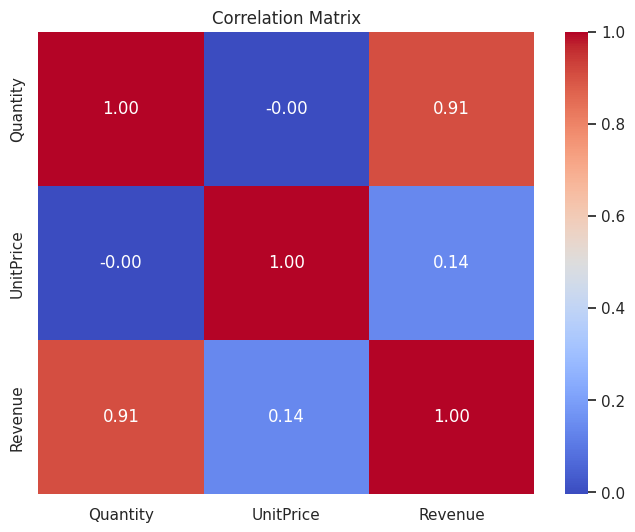

In [76]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# **Quantity vs Revenue**

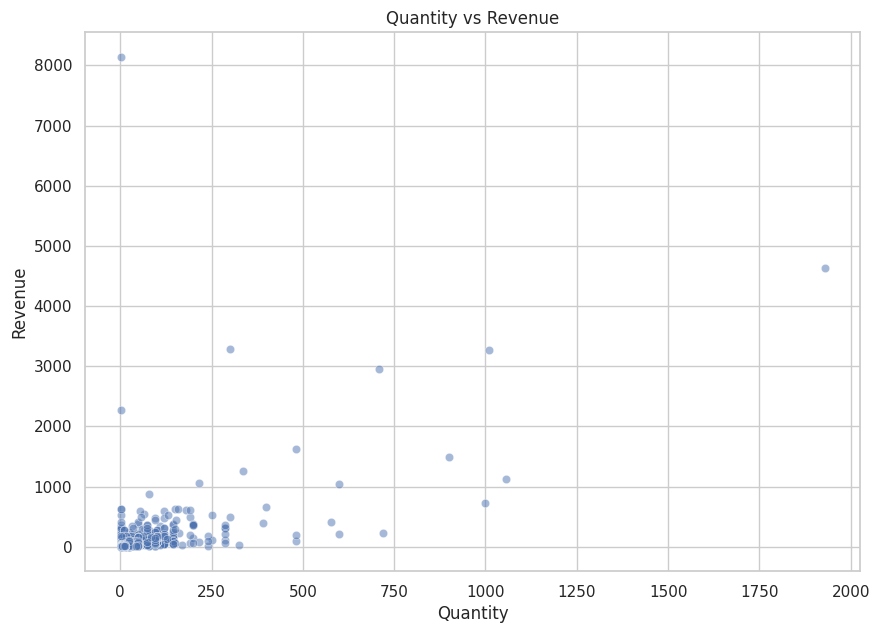

In [77]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=sales_df.sample(
        min(10000, len(sales_df)),
        random_state=42
    ),
    x="Quantity",
    y="Revenue",
    alpha=0.5
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.show()

# **Unit Price vs Quantity**

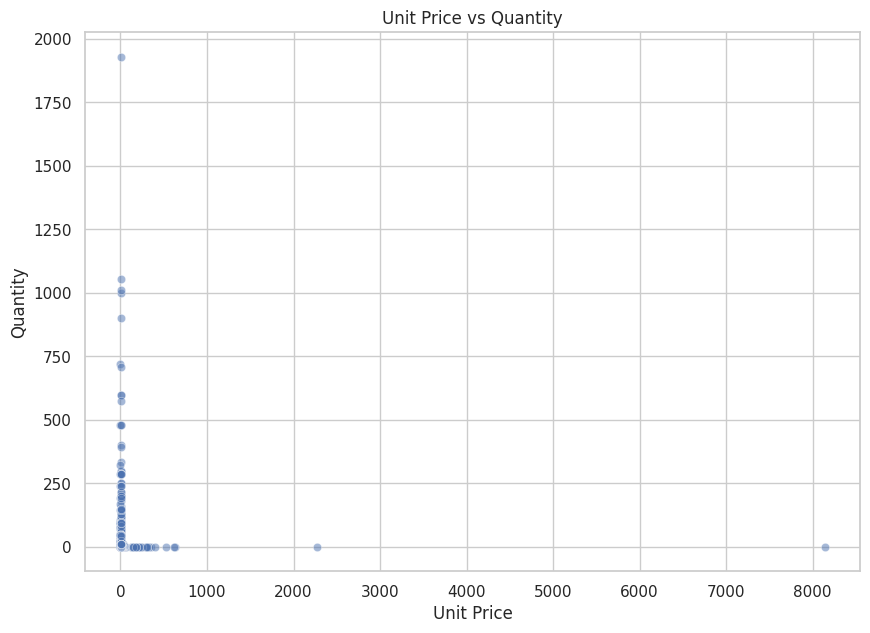

In [78]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=sales_df.sample(
        min(10000, len(sales_df)),
        random_state=42
    ),
    x="UnitPrice",
    y="Quantity",
    alpha=0.5
)

plt.title("Unit Price vs Quantity")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")

plt.show()

# **Create Final KPI Table**

In [79]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Units Sold",
        "Average Order Value",
        "Average Units per Order",
        "Cancellation Rate",
        "Repeat Customer Rate"
    ],

    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_products,
        total_units,
        average_order_value,
        average_units_per_order,
        cancellation_rate,
        repeat_rate
    ]
})

kpi

,Metric,Value
0,Total Revenue,1.064211e+07
1,Total Orders,1.996000e+04
2,Total Customers,4.338000e+03
3,Total Products,3.922000e+03
4,Total Units Sold,5.572420e+06
5,Average Order Value,5.331719e+02
6,Average Units per Order,2.791794e+02
7,Cancellation Rate,1.723871e+00
8,Repeat Customer Rate,6.558322e+01


# **Automated Business Summary**

In [80]:
print("=" * 60)
print("ONLINE RETAIL BUSINESS ANALYSIS")
print("=" * 60)

print(f"Total Revenue       : £{total_revenue:,.2f}")
print(f"Total Orders        : {total_orders:,}")
print(f"Total Customers     : {total_customers:,}")
print(f"Total Products      : {total_products:,}")
print(f"Total Units Sold    : {total_units:,}")
print(f"Average Order Value : £{average_order_value:,.2f}")

print("\n--- TOP COUNTRY ---")

top_country = country.loc[
    country["Revenue"].idxmax(),
    "Country"
]

print(top_country)

print("\n--- TOP PRODUCT ---")

top_product = product.loc[
    product["Revenue"].idxmax(),
    "Description"
]

print(top_product)

print("\n--- CUSTOMER ANALYSIS ---")

print(
    f"Repeat Customer Rate: {repeat_rate:.2f}%"
)

print("\n--- CANCELLATIONS ---")

print(
    f"Cancellation Rate: {cancellation_rate:.2f}%"
)

ONLINE RETAIL BUSINESS ANALYSIS
Total Revenue       : £10,642,110.80
Total Orders        : 19,960
Total Customers     : 4,338
Total Products      : 3,922
Total Units Sold    : 5,572,420
Average Order Value : £533.17

--- TOP COUNTRY ---
United Kingdom

--- TOP PRODUCT ---
DOTCOM POSTAGE

--- CUSTOMER ANALYSIS ---
Repeat Customer Rate: 65.58%

--- CANCELLATIONS ---
Cancellation Rate: 1.72%
